In [81]:
import numpy as np
import pandas as pd


In [82]:
df = pd.read_csv('/content/placement.csv')



In [83]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [84]:
df.shape

(100, 4)

In [85]:
# Steps

# 0. Preprocess + EDA + Feature Selection done
# 1. Extract input and output cols do
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [87]:
df=df.iloc[:,1:]

In [88]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [89]:
import matplotlib.pyplot as plt

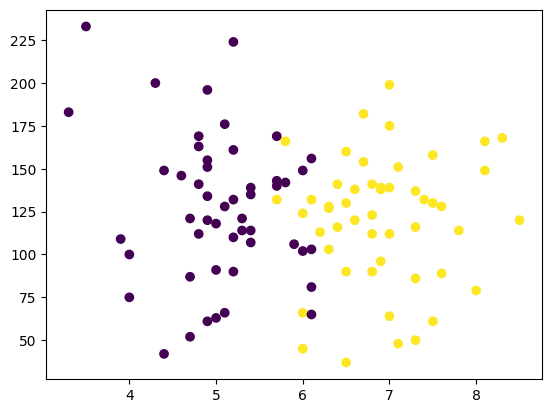

In [90]:
plt.scatter(df["cgpa"],df["iq"], c=df["placement"])

In [91]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [92]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [93]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [94]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [95]:
X_test

,cgpa,iq
80,4.9,196.0
16,5.2,224.0
38,6.5,160.0
33,6.0,149.0
39,4.6,146.0
89,4.9,151.0
70,6.3,127.0
81,5.4,107.0
64,7.0,64.0
60,6.9,139.0


In [96]:
X_train

,cgpa,iq
7,5.0,63.0
44,7.5,61.0
19,5.2,132.0
48,6.6,138.0
4,5.8,142.0
...,...,...
62,6.0,102.0
87,5.7,132.0
32,7.0,139.0
66,6.9,96.0


In [97]:
from sklearn.preprocessing import StandardScaler

In [98]:
scaler= StandardScaler()

In [99]:
X_train =scaler.fit_transform(X_train)

In [100]:
X_test=scaler.fit_transform(X_test)

In [101]:
y_train

,placement
7,0
44,1
19,0
48,1
4,0
...,...
62,0
87,1
32,1
66,1


In [102]:
from sklearn.linear_model import LogisticRegression

In [103]:
clf = LogisticRegression()

MODEL TRAINING

In [104]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [105]:
y_pred =clf.predict(X_test)

In [106]:
y_test

,placement
80,0
16,0
38,1
33,0
39,0
89,0
70,1
81,0
64,1
60,1


In [107]:
from sklearn.metrics import accuracy_score


In [108]:
accuracy_score(y_test,y_pred)

0.9

In [109]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

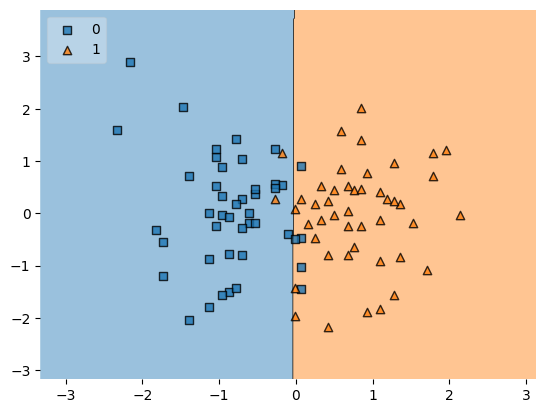

In [110]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [111]:
import pickle

In [112]:
pickle.dump(clf,open('model.pkl','wb'))